In [753]:
#hide
options(jupyter.plot_scale=3)
options(repr.plot.width=6,repr.plot.height=6,repr.plot.res=300)

# (노트) 분류분석 (3)

- toc:true
- branch: master
- badges: true
- comments: true
- author: 최규빈
- hide: false
- categories: [ADsP]

### 토익, 학점 --> 합격 

In [812]:
토익=c(300,350,400,450,
     500,550,500,550,
     750,700,750,700,
     950)
학점=c(1,2,1,2,
     2,3,2,2,
     3,4,4,4,
     0.5)
합격=c(0,0,0,0,
     0,1,1,0,
     1,1,1,1,
     1)

In [813]:
X = cbind(토익,학점)
y = 합격

In [814]:
데이터 = cbind(X,y)
데이터 

토익,학점,y
300,1.0,0
350,2.0,0
400,1.0,0
450,2.0,0
500,2.0,0
550,3.0,1
500,2.0,1
550,2.0,0
750,3.0,1
700,4.0,1


### 로지스틱 회귀분석

`-` `합격 = b0 + 토익*b1 + 학점*b2` 를 만족하는 적절한 b0, b1, b2를 구하고 싶음 --> 회귀모형이네

In [815]:
lm(합격 ~ 토익+학점)


Call:
lm(formula = 합격 ~ 토익 + 학점)

Coefficients:
(Intercept)         토익         학점  
   -0.84379      0.00181      0.14707  


In [816]:
b0= -1.1914414
b1= 0.0007207
b2= 0.4099099  

- 모형: `합격 = b0 + 토익*b1 + 학점*b2`

확인해보자. 

In [817]:
X

토익,학점
300,1.0
350,2.0
400,1.0
450,2.0
500,2.0
550,3.0
500,2.0
550,2.0
750,3.0
700,4.0


In [818]:
b0 + 300*b1 + 2*b2 # 1번관측치가 합격할 확률 (음수우..?)

[1] -0.1554116

In [819]:
b0 + 700*b1 + 4*b2 # 마지막관측치가 합격할 확률

[1] 0.9526882

`-` 관찰: 학생들의 학점,토익점수를 넣기만 하면 확률이 예측되는군? 

`-` 학점 4.5, 토익 995를 대입해보자. --> 합격확률은 거의 1

In [820]:
b0 + 995*b1 + 4.5*b2

[1] 1.37025

`-` 1이 넘는다? $\to$ 음수도 안나오고 1도 안넘었으면 좋겠는데? 

`-` 로지스틱이라는걸 만들자. 

`-` X에 시그모이드를 취하자. 그러면 모형은

```
분자 = 1+exp(b0 + 토익*b1 + 학점*b2)
분모 = exp(b0 + 토익*b1 + 학점*b2)
합격 = 분모/분자 
```

식으로 쓰면 

$$y \approx \frac{\exp(b_0+b_1X_1+b_2X_2)}{1+\exp(b_0+b_1X_1+b_2X_2)}=\frac{1}{1+\exp(-b_0-b_1X_1-b_2X_2)}$$ 

`-` 넣어보자. 

In [821]:
분자_ =exp(b0 + 995*b1 + 4.5*b2)
분모_ =exp(b0 + 995*b1 + 4.5*b2)+1
합격_ = 분자_/분모_
합격_

[1] 0.7974205

- 0~1사이로 떨어지김함. 그런데 토익995에 학점 4.5인데 합격률이 너무 낮음 

`-` 다른 학생을 넣어보자. 

In [822]:
분자_=exp(b0 + 700*b1 + 4*b2)
분모_=exp(b0 + 700*b1 + 4*b2)+1
합격_ = 분자_/분모_
합격_

[1] 0.7216555

`-` 역시 좀 낮다? --> 사실 이건 모형이 $y \approx b_0 + b_1 X_1 + b_2X_2$ 라고 생각하고 찾은 최적의 $b_0,b_1,b_2$임. $y \approx \frac{\exp(b_0+b_1X_1+b_2X_2)}{1+\exp(b_0+b_1X_1+b_2X_2)}$ 이걸 가정한건 아니었다


`-` 애초에 $y \approx \frac{\exp(b_0+b_1X_1+b_2X_2)}{1+\exp(b_0+b_1X_1+b_2X_2)}$를 가정하면 계수를 찾으면 좀 다를수 있음. 실제로 다름. 

`-` 그걸해보자. --> lm이 아니라 glm 이용 

In [823]:
glm(합격 ~ 토익+학점)


Call:  glm(formula = 합격 ~ 토익 + 학점)

Coefficients:
(Intercept)         토익         학점  
   -0.84379      0.00181      0.14707  

Degrees of Freedom: 12 Total (i.e. Null);  10 Residual
Null Deviance:	    3.231 
Residual Deviance: 1.023 	AIC: 11.85

`-` 이건 아까 회귀랑 똑같음. glm만 쓰면 되는게 아니라 아래와 같이 해야함 

In [824]:
glm(합격 ~ 토익+학점,family=binomial)


Call:  glm(formula = 합격 ~ 토익 + 학점, family = binomial)

Coefficients:
(Intercept)         토익         학점  
  -17.92394      0.02081      3.18837  

Degrees of Freedom: 12 Total (i.e. Null);  10 Residual
Null Deviance:	    17.94 
Residual Deviance: 5.079 	AIC: 11.08

`-` 다시 넣어보자. 

In [825]:
b0=-13.5848
b1= 0.0149   
b2= 2.5694 
분자_=exp(b0 + 700*b1 + 3.0*b2)
분모_=exp(b0 + 700*b1 + 3.0*b2)+1
합격_ = 분자_/분모_
합격_

[1] 0.9895784

In [826]:
분자_=exp(b0 + 995*b1 + 4.5*b2)
분모_=exp(b0 + 995*b1 + 4.5*b2)+1
합격_ = 분자_/분모_
합격_

[1] 0.9999972

- 상당히 그럴듯함 

`-` 해석이 가능함: 토익 700, 학점 4.0인 학생이 토익을 995로 올리고 학점을 4.5로 높이면 합격률이 98 -> 99로 상승 

#### 의사결정나무 

`-` 의사결정나무로 분석해보자. rpart로드 

In [827]:
library(rpart)

`-` 현재합격변수

In [828]:
합격

[1] 0 0 0 0 0 1 1 0 1 1 1 1 1

- 이게 입력으로가면 범주로 봐야하나 숫자로 봐야하나? (트리는 y가 연속이어도 가능하고 종속이어도 가능하므로 이렇게 종속변수를 넣으면 컴퓨터가 헷갈려함)

`-` 변수를 명확하게 범주형으로 바꾸자. 

In [829]:
합격2 =  c('불합격','불합격','불합격','불합격','불합격','합격','합격','불합격','합격','합격','합격','합격','합격') # 트리는 y가 연속이어도가능하고 종속이어도 가능하므로 y를 0,1로 넣으면 이걸 연속형으로 착각한다. 그래서 바꿔줌

`-` 의사결정나무 분석 

In [830]:
의사결정나무결과 = rpart(합격2 ~ 토익 + 학점)
의사결정나무결과

n= 13 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

1) root 13 6 합격 (0.4615385 0.5384615) *

- 아무것도 가지가 안생겼다? 

`-` 의사결정나무 특징: 데이터가 어느정도 있어야 돌아감. (정지규칙때문) 

In [831]:
합격3=rep(합격2,30)
토익2=rep(토익,30)
학점2=rep(학점,30)

In [832]:
length(합격3)

[1] 390

In [833]:
부먹=sample(c('부먹','찍먹'),size=390,replace=T)
민초=sample(c('먹','안먹'),size=390,replace=T)
주민번호끝자리=sample(c('홀','짝'),size=390,replace=T)
학번끝자리=sample(c('홀','짝'),size=390,replace=T)
더미1=sample(c('홀','짝'),size=390,replace=T)
더미2=sample(c('홀','짝'),size=390,replace=T)
더미3=sample(c('홀','짝'),size=390,replace=T)
더미4=sample(c('홀','짝'),size=390,replace=T)
더미5=sample(c('홀','짝'),size=390,replace=T)
더미6=sample(c('홀','짝'),size=390,replace=T)

In [834]:
데이터2=data.frame(합격=합격3,
                토익=토익2,
                학점=학점2,
                부먹=부먹,
                민초=민초,
                주민번호끝자리=주민번호끝자리,
                학번끝자리=학번끝자리,
                더미1=더미1,
                더미2=더미2,
                더미3=더미3,
                더미4=더미4,
                더미5=더미5,
                더미6=더미6)
데이터2

합격,토익,학점,부먹,민초,주민번호끝자리,학번끝자리,더미1,더미2,더미3,더미4,더미5,더미6
<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
불합격,300,1.0,부먹,먹,짝,짝,홀,짝,짝,짝,짝,짝
불합격,350,2.0,부먹,안먹,짝,짝,홀,짝,홀,홀,짝,짝
불합격,400,1.0,부먹,안먹,홀,짝,홀,짝,홀,짝,짝,홀
불합격,450,2.0,부먹,안먹,짝,홀,짝,짝,홀,홀,짝,짝
불합격,500,2.0,찍먹,안먹,홀,짝,홀,홀,짝,짝,짝,홀
합격,550,3.0,찍먹,먹,홀,짝,짝,홀,홀,홀,짝,짝
합격,500,2.0,찍먹,먹,홀,짝,홀,짝,홀,짝,짝,짝
불합격,550,2.0,찍먹,먹,홀,홀,홀,홀,홀,홀,홀,짝
합격,750,3.0,부먹,안먹,짝,홀,홀,홀,홀,홀,홀,짝


`-` 이제돌려보자. 

In [835]:
의사결정나무결과=rpart(data=데이터2, 합격~.)
의사결정나무결과

n= 390 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

  1) root 390 180 합격 (0.4615385 0.5384615)  
    2) 토익< 625 240  60 불합격 (0.7500000 0.2500000)  
      4) 학점< 2.5 210  30 불합격 (0.8571429 0.1428571)  
        8) 토익< 475 120   0 불합격 (1.0000000 0.0000000) *
        9) 토익>=475 90  30 불합격 (0.6666667 0.3333333)  
         18) 토익>=525 30   0 불합격 (1.0000000 0.0000000) *
         19) 토익< 525 60  30 불합격 (0.5000000 0.5000000)  
           38) 더미1=홀 34  14 불합격 (0.5882353 0.4117647)  
             76) 주민번호끝자리=짝 14   3 불합격 (0.7857143 0.2142857) *
             77) 주민번호끝자리=홀 20   9 합격 (0.4500000 0.5500000)  
              154) 민초=안먹 12   4 불합격 (0.6666667 0.3333333) *
              155) 민초=먹 8   1 합격 (0.1250000 0.8750000) *
           39) 더미1=짝 26  10 합격 (0.3846154 0.6153846) *
      5) 학점>=2.5 30   0 합격 (0.0000000 1.0000000) *
    3) 토익>=625 150   0 합격 (0.0000000 1.0000000) *

`-` 결과보기 너무 힘드니까 그림으로 그리자 

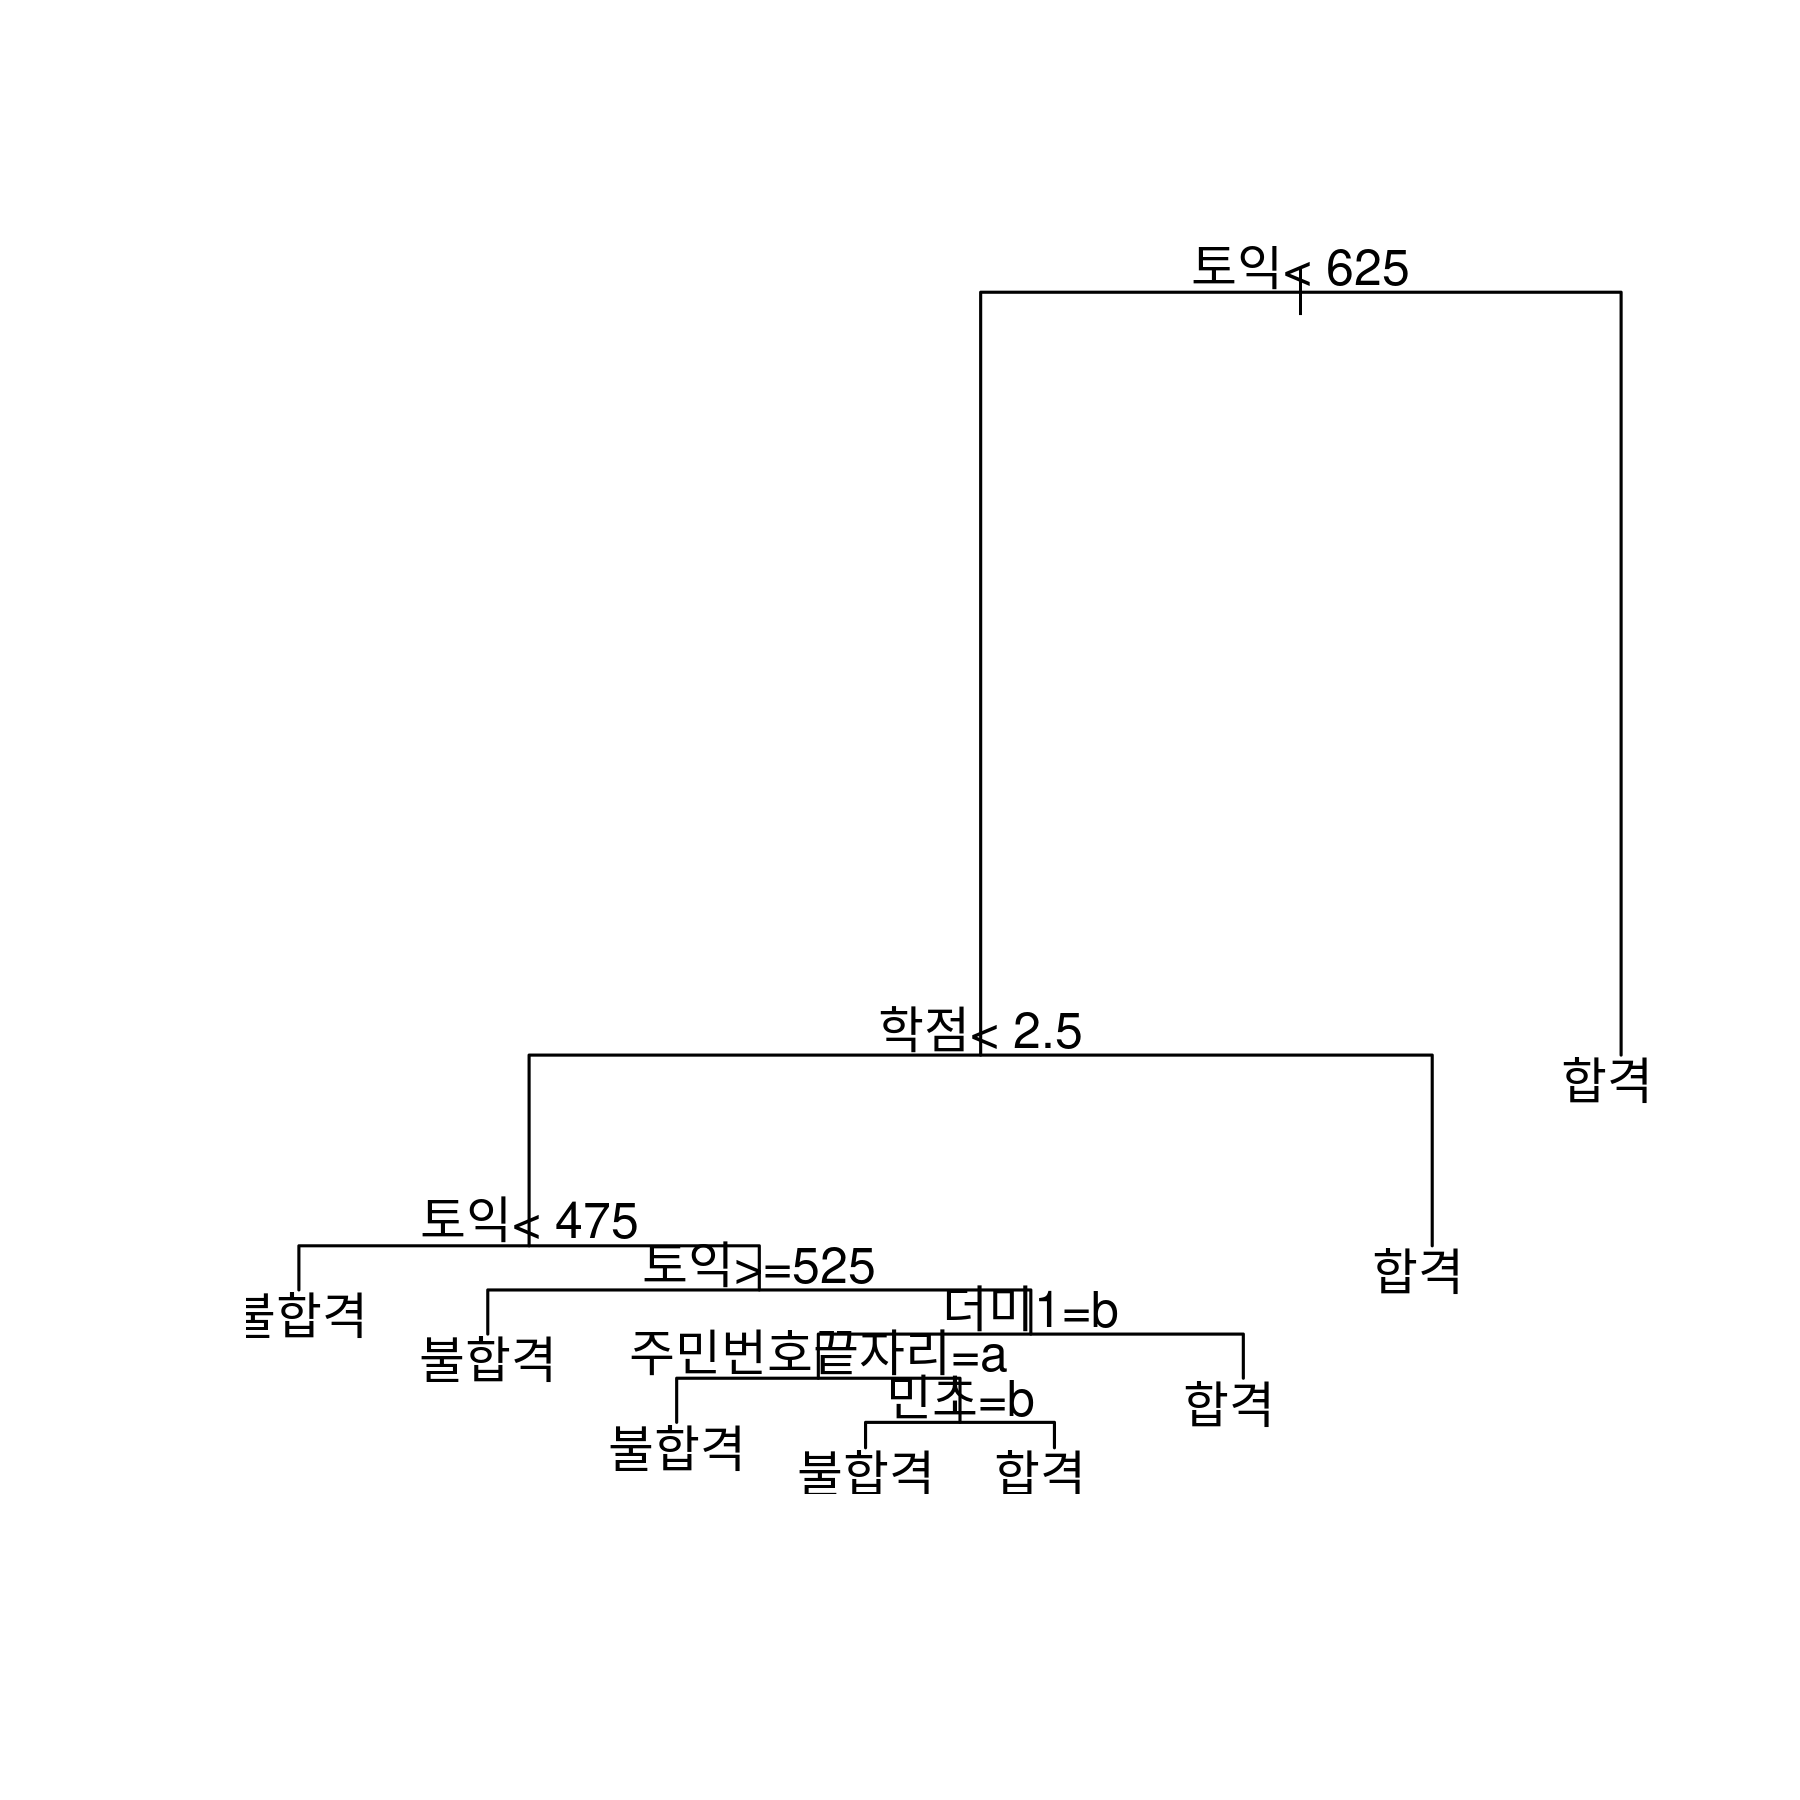

In [836]:
plot(의사결정나무결과)
text(의사결정나무결과)

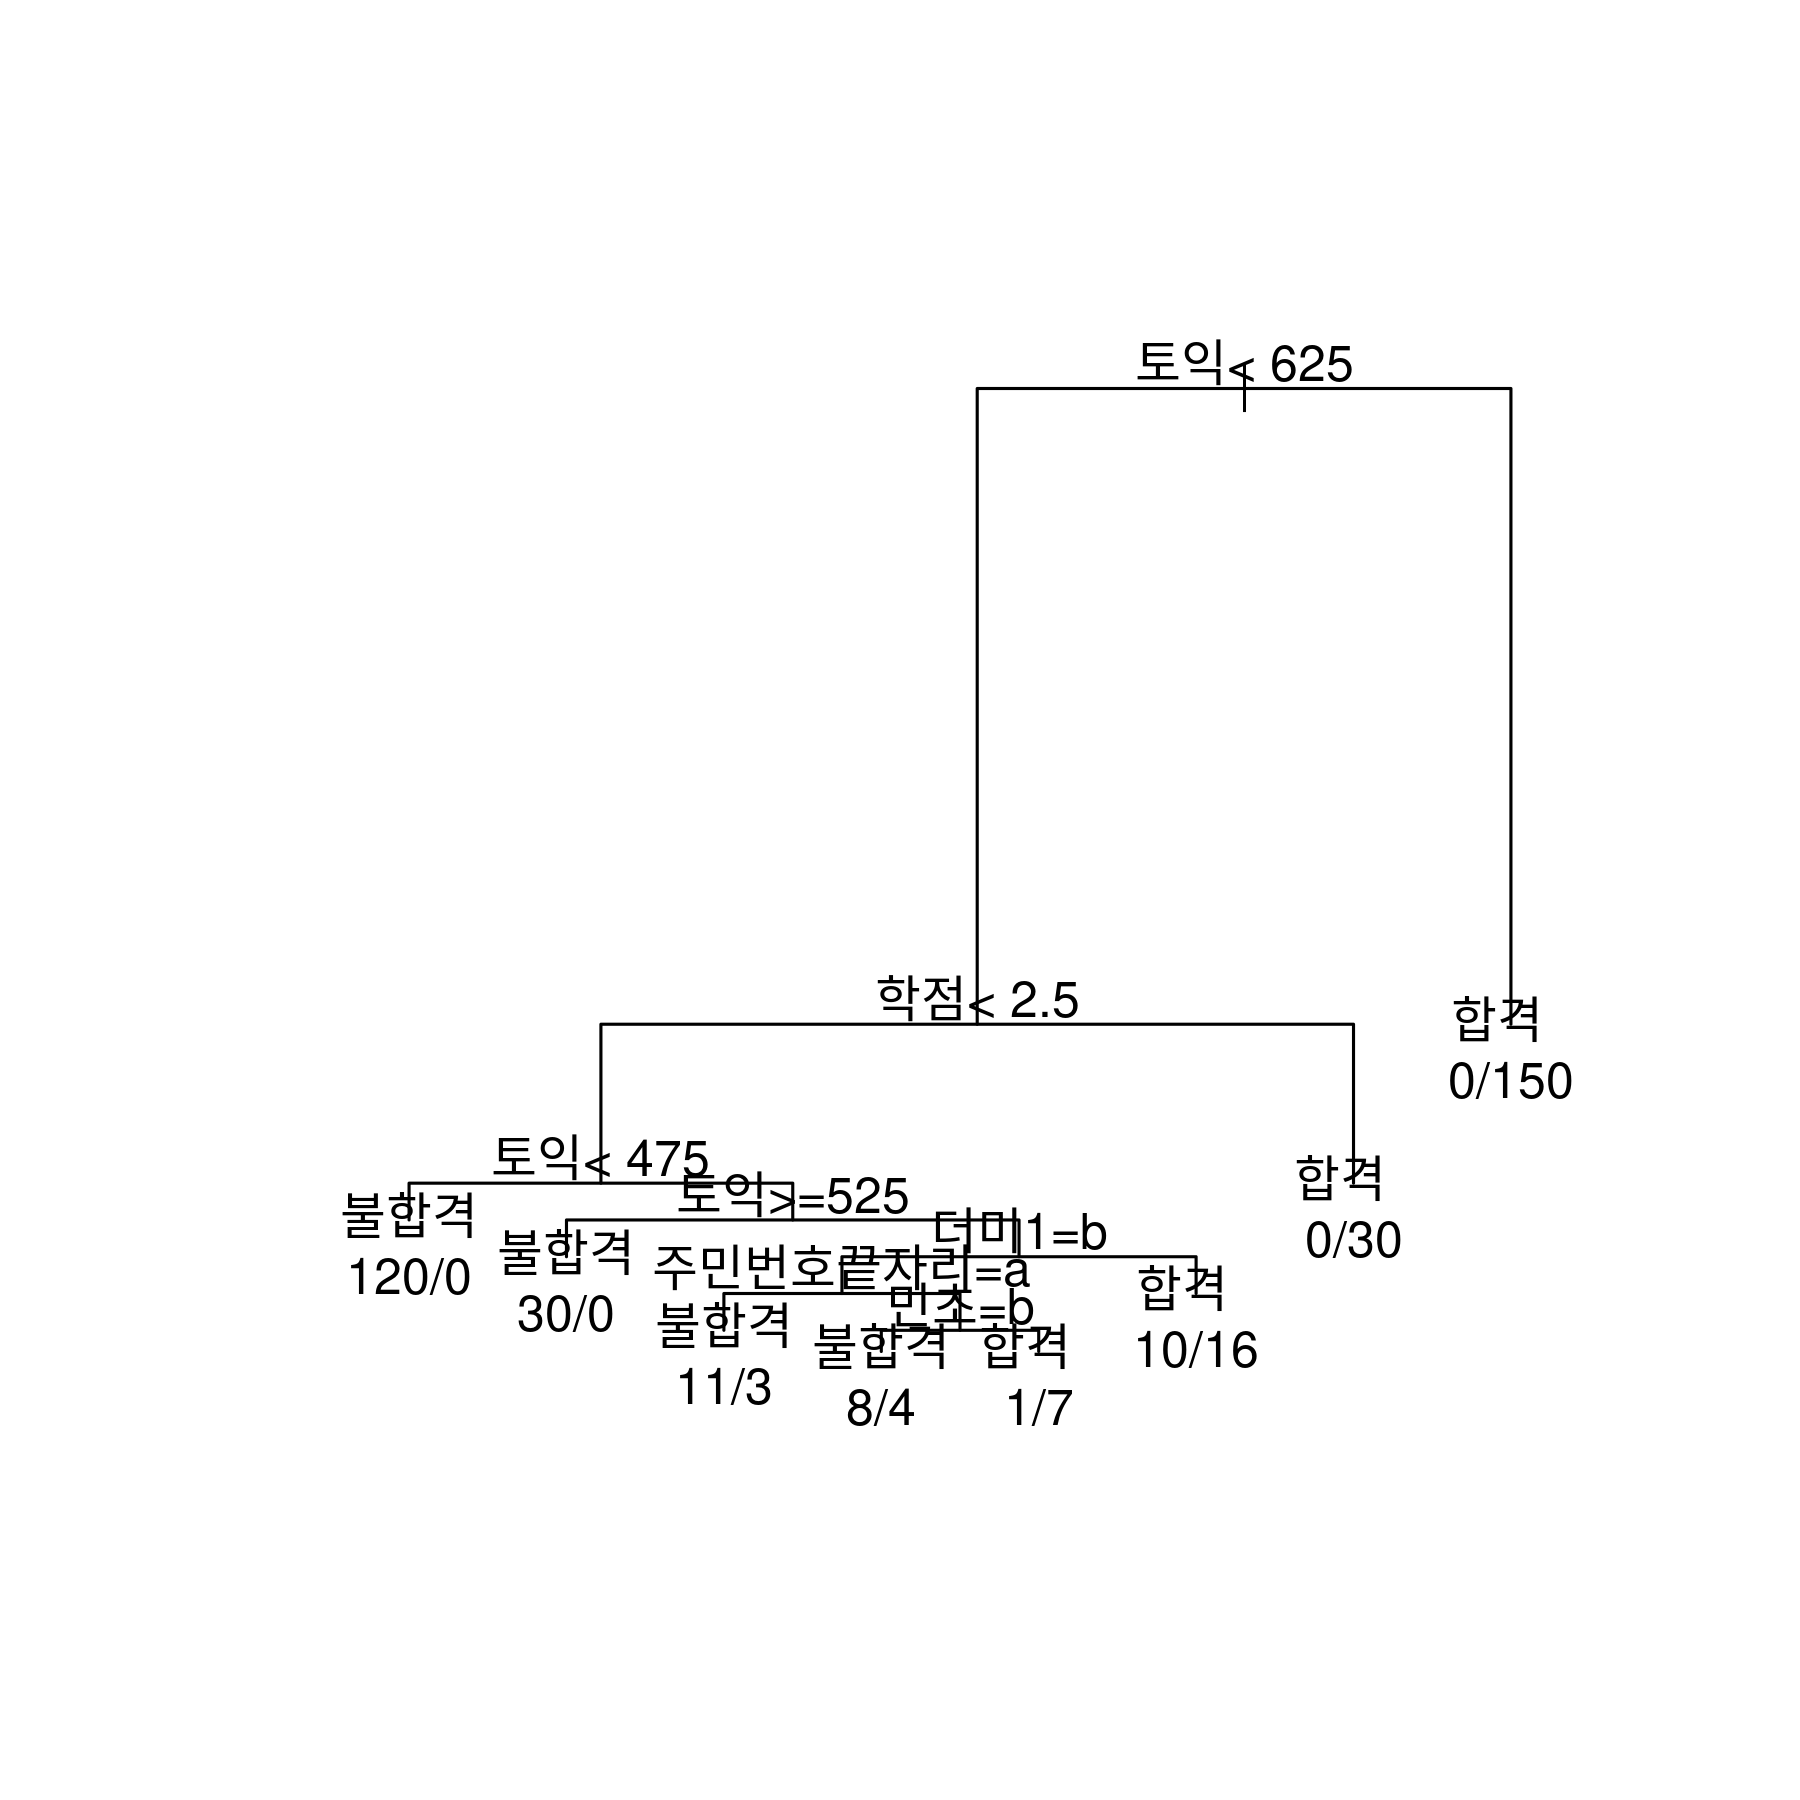

In [837]:
plot(의사결정나무결과,margin=0.1)
text(의사결정나무결과,use.n=T)

- 더미변수로 분류하고 있음.. $\to$ 오버핏 

`-` 가지치기

In [838]:
prune(의사결정나무결과,cp=0.1) ## cp=얼마나 가지를 칠지결정함, cp가 클수록 가지를 많이침 

n= 390 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

1) root 390 180 합격 (0.4615385 0.5384615)  
  2) 토익< 625 240  60 불합격 (0.7500000 0.2500000)  
    4) 학점< 2.5 210  30 불합격 (0.8571429 0.1428571) *
    5) 학점>=2.5 30   0 합격 (0.0000000 1.0000000) *
  3) 토익>=625 150   0 합격 (0.0000000 1.0000000) *

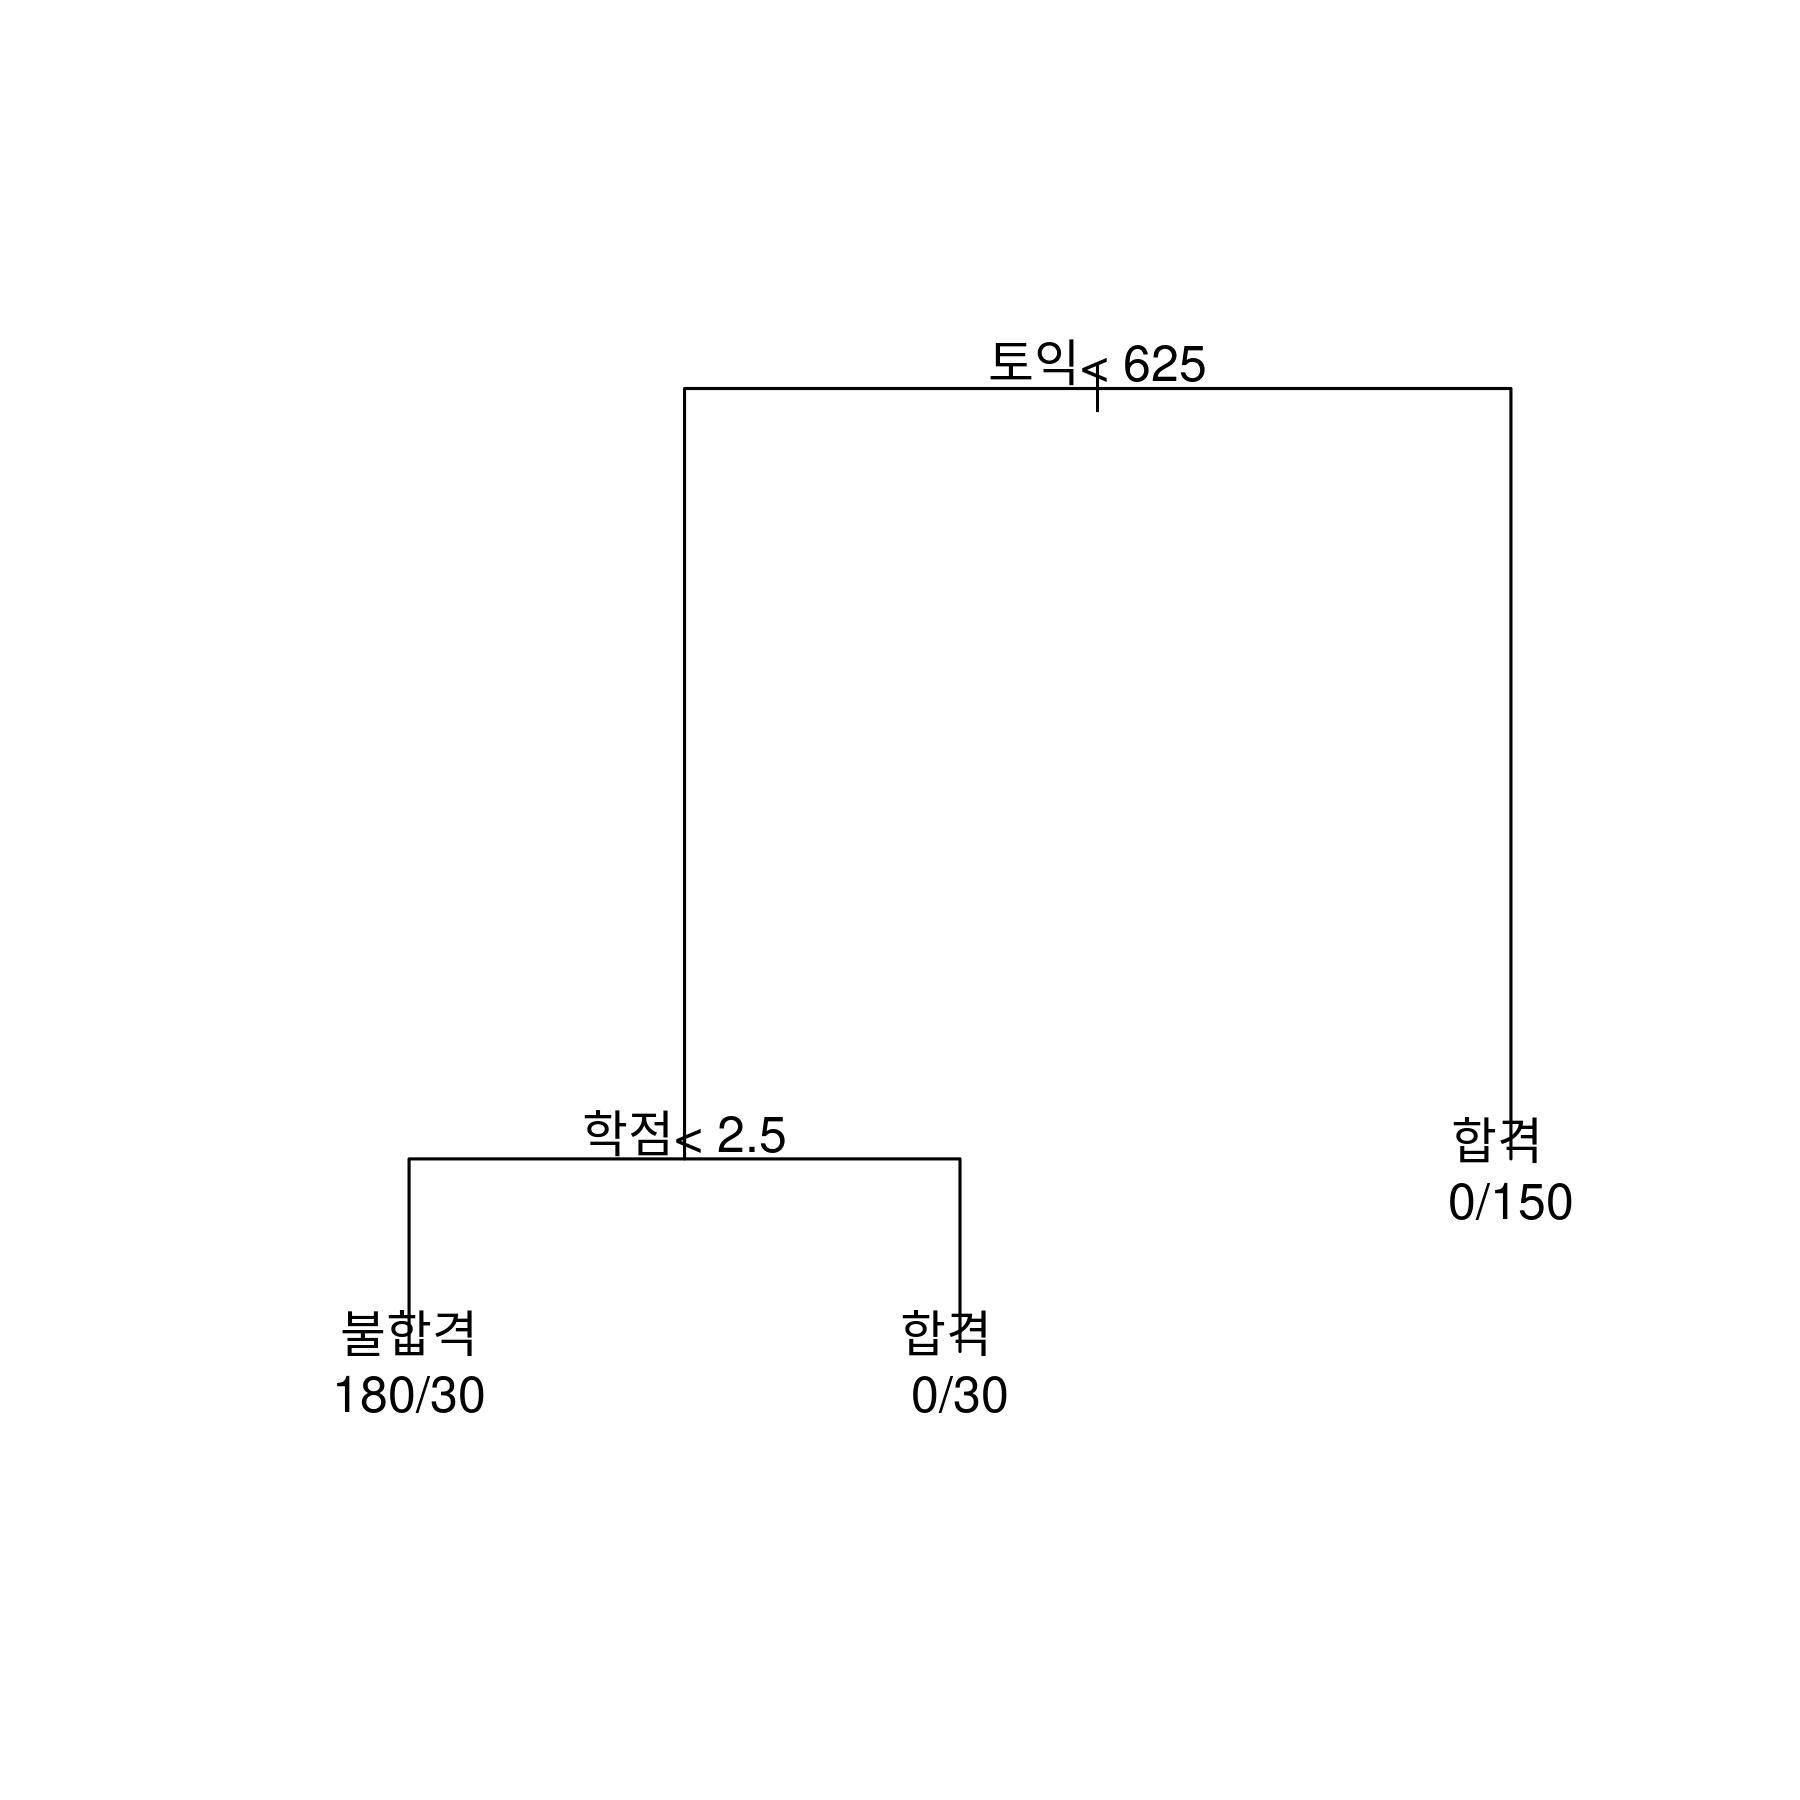

In [839]:
가지를친결과=prune(의사결정나무결과,cp=0.1)
plot(가지를친결과,margin=0.1)
text(가지를친결과,use.n=T)

### 이상치 

`-` 로지스틱회귀

In [840]:
glm(data=데이터2,factor(합격)~토익+학점, family='binomial')


Call:  glm(formula = factor(합격) ~ 토익 + 학점, family = "binomial", 
    data = 데이터2)

Coefficients:
(Intercept)         토익         학점  
  -17.92394      0.02081      3.18837  

Degrees of Freedom: 389 Total (i.e. Null);  387 Residual
Null Deviance:	    538.3 
Residual Deviance: 152.4 	AIC: 158.4

`-` 실수로 데이터 하나를 잘못입력함 

In [841]:
head(데이터2)

,합격,토익,학점,부먹,민초,주민번호끝자리,학번끝자리,더미1,더미2,더미3,더미4,더미5,더미6
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,불합격,300,1,부먹,먹,짝,짝,홀,짝,짝,짝,짝,짝
2,불합격,350,2,부먹,안먹,짝,짝,홀,짝,홀,홀,짝,짝
3,불합격,400,1,부먹,안먹,홀,짝,홀,짝,홀,짝,짝,홀
4,불합격,450,2,부먹,안먹,짝,홀,짝,짝,홀,홀,짝,짝
5,불합격,500,2,찍먹,안먹,홀,짝,홀,홀,짝,짝,짝,홀
6,합격,550,3,찍먹,먹,홀,짝,짝,홀,홀,홀,짝,짝


In [842]:
데이터2[6,]$토익=-99999

In [843]:
head(데이터2)

,합격,토익,학점,부먹,민초,주민번호끝자리,학번끝자리,더미1,더미2,더미3,더미4,더미5,더미6
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,불합격,300,1,부먹,먹,짝,짝,홀,짝,짝,짝,짝,짝
2,불합격,350,2,부먹,안먹,짝,짝,홀,짝,홀,홀,짝,짝
3,불합격,400,1,부먹,안먹,홀,짝,홀,짝,홀,짝,짝,홀
4,불합격,450,2,부먹,안먹,짝,홀,짝,짝,홀,홀,짝,짝
5,불합격,500,2,찍먹,안먹,홀,짝,홀,홀,짝,짝,짝,홀
6,합격,-99999,3,찍먹,먹,홀,짝,짝,홀,홀,홀,짝,짝


- 토익이 올라갈수록 합격한다 생각했었음 
- 그런데 토익이 -99999인데 합격인 사람이 발생함
- 컴퓨터는 굉장한 혼란에 빠질것임 

`-` 다시돌려보자. 

In [844]:
glm(data=데이터2,factor(합격)~토익+학점, family='binomial')


Call:  glm(formula = factor(합격) ~ 토익 + 학점, family = "binomial", 
    data = 데이터2)

Coefficients:
(Intercept)         토익         학점  
 -2.804e+00   -2.993e-06    1.308e+00  

Degrees of Freedom: 389 Total (i.e. Null);  387 Residual
Null Deviance:	    538.3 
Residual Deviance: 401.3 	AIC: 407.3

- 토익에 해당하는 계수를 그냥 0으로 만들어버림. $\to$ 토익은 생각 안해
- 모형자체가 확 틀어짐 

`-` 의사결정나무는? 

n= 390 

node), split, n, loss, yval, (yprob)
      * denotes terminal node

  1) root 390 180 합격 (0.4615385 0.5384615)  
    2) 토익< 625 240  60 불합격 (0.7500000 0.2500000)  
      4) 학점< 2.5 210  30 불합격 (0.8571429 0.1428571)  
        8) 토익< 475 120   0 불합격 (1.0000000 0.0000000) *
        9) 토익>=475 90  30 불합격 (0.6666667 0.3333333)  
         18) 토익>=525 30   0 불합격 (1.0000000 0.0000000) *
         19) 토익< 525 60  30 불합격 (0.5000000 0.5000000)  
           38) 더미1=홀 34  14 불합격 (0.5882353 0.4117647)  
             76) 주민번호끝자리=짝 14   3 불합격 (0.7857143 0.2142857) *
             77) 주민번호끝자리=홀 20   9 합격 (0.4500000 0.5500000)  
              154) 민초=안먹 12   4 불합격 (0.6666667 0.3333333) *
              155) 민초=먹 8   1 합격 (0.1250000 0.8750000) *
           39) 더미1=짝 26  10 합격 (0.3846154 0.6153846) *
      5) 학점>=2.5 30   0 합격 (0.0000000 1.0000000) *
    3) 토익>=625 150   0 합격 (0.0000000 1.0000000) *

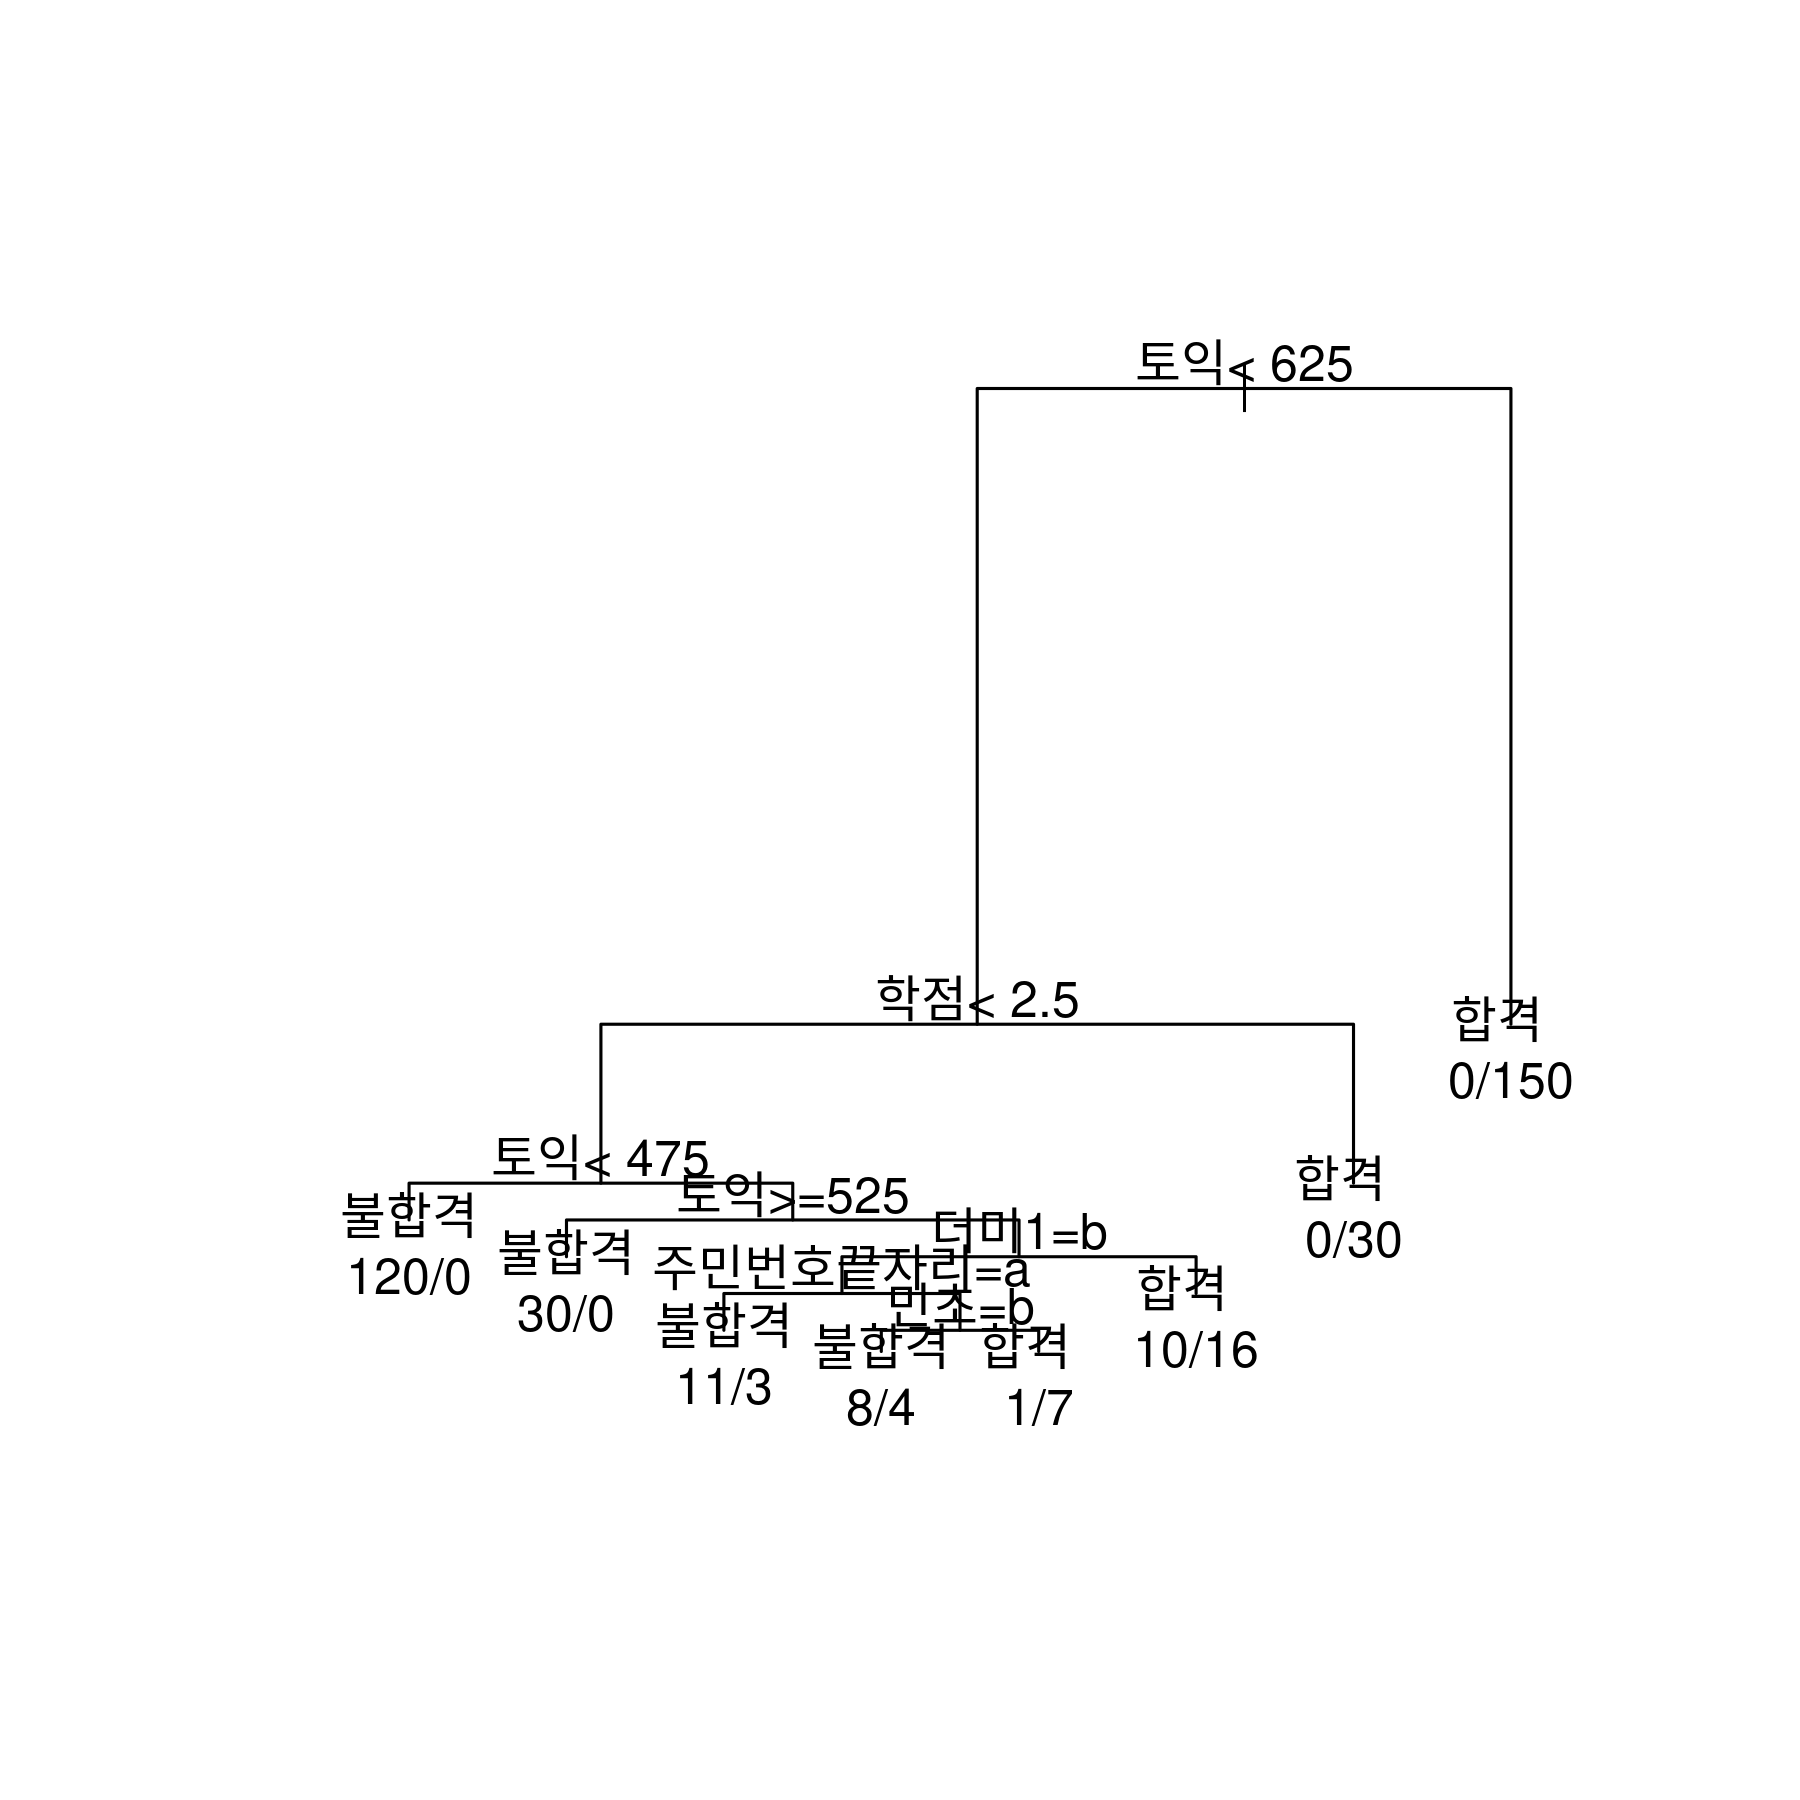

In [845]:
의사결정나무결과=rpart(data=데이터2, 합격~.)
의사결정나무결과
plot(의사결정나무결과,margin=0.1)
text(의사결정나무결과,use.n=T)

- 별타격없음.. 그냥 분류하나 잘못되는것 뿐임. (불순도가 쥐꼬리 만큼 달라지긴 하겠지) 
- 토익 < 625, 학점 < 2.5 

### 배깅 

`-` 리샘플링기법 

In [898]:
dim(데이터2)

[1] 390  13

In [902]:
샘플링할인덱스=sort(sample(1:390,size=390,replace=T))
샘플링할인덱스

[1]   1   2   2   2   4   7   8   9  10  12  14  15  15  16  19  19  19  19
 [19]  20  21  23  24  25  25  25  26  28  28  29  30  30  30  30  31  32  33
 [37]  34  35  37  39  39  40  42  42  42  43  43  43  44  44  44  44  45  46
 [55]  46  47  47  48  51  52  54  55  55  57  57  58  59  61  61  61  63  64
 [73]  68  69  70  71  72  73  74  78  78  79  80  80  80  81  82  84  84  84
 [91]  85  88  88  91  91  94  94  95  95  99 101 102 102 104 104 105 106 107
[109] 107 107 107 108 109 111 112 112 114 114 116 117 117 117 119 120 120 122
[127] 122 123 123 127 127 128 129 129 129 131 134 134 135 136 136 137 137 139
[145] 139 140 140 142 142 142 144 144 145 146 151 153 154 154 155 158 159 162
[163] 163 164 165 165 166 167 168 168 169 170 170 172 173 173 175 176 178 179
[181] 182 182 182 183 184 185 185 186 188 189 189 191 194 195 196 200 201 201
[199] 201 201 203 203 204 204 206 206 206 206 206 207 207 210 210 212 213 215
[217] 215 217 217 218 220 220 222 223 225 226 226 226 226 228 229 231 232 234
[235] 234 235 236 238 239 239 240 241 241 242 243 245 249 251 252 253 254 255
[253] 255 257 257 258 259 261 262 264 264 264 264 265 266 267 267 271 272 272
[271] 272 272 272 274 275 275 281 281 281 281 283 284 284 285 286 287 289 289
[289] 289 292 292 293 293 295 295 295 297 297 298 300 301 303 303 304 304 306
[307] 308 308 309 310 310 311 311 314 315 316 317 318 318 320 320 322 322 327
[325] 327 328 329 329 330 332 332 333 333 334 334 334 335 336 337 338 338 341
[343] 343 347 348 349 349 353 354 354 354 355 355 356 357 358 358 359 361 361
[361] 362 362 363 363 363 364 365 365 366 367 369 372 372 374 375 376 377 377
[379] 378 378 379 379 383 385 386 386 387 388 389 390

In [903]:
부스트랩=데이터2[샘플링할인덱스,]
head(부스트랩)

,합격,토익,학점,부먹,민초,주민번호끝자리,학번끝자리,더미1,더미2,더미3,더미4,더미5,더미6
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,불합격,300,1,부먹,먹,짝,짝,홀,짝,짝,짝,짝,짝
2,불합격,350,2,부먹,안먹,짝,짝,홀,짝,홀,홀,짝,짝
2.1,불합격,350,2,부먹,안먹,짝,짝,홀,짝,홀,홀,짝,짝
2.2,불합격,350,2,부먹,안먹,짝,짝,홀,짝,홀,홀,짝,짝
4,불합격,450,2,부먹,안먹,짝,홀,짝,짝,홀,홀,짝,짝
7,합격,500,2,찍먹,먹,홀,짝,홀,짝,홀,짝,짝,짝


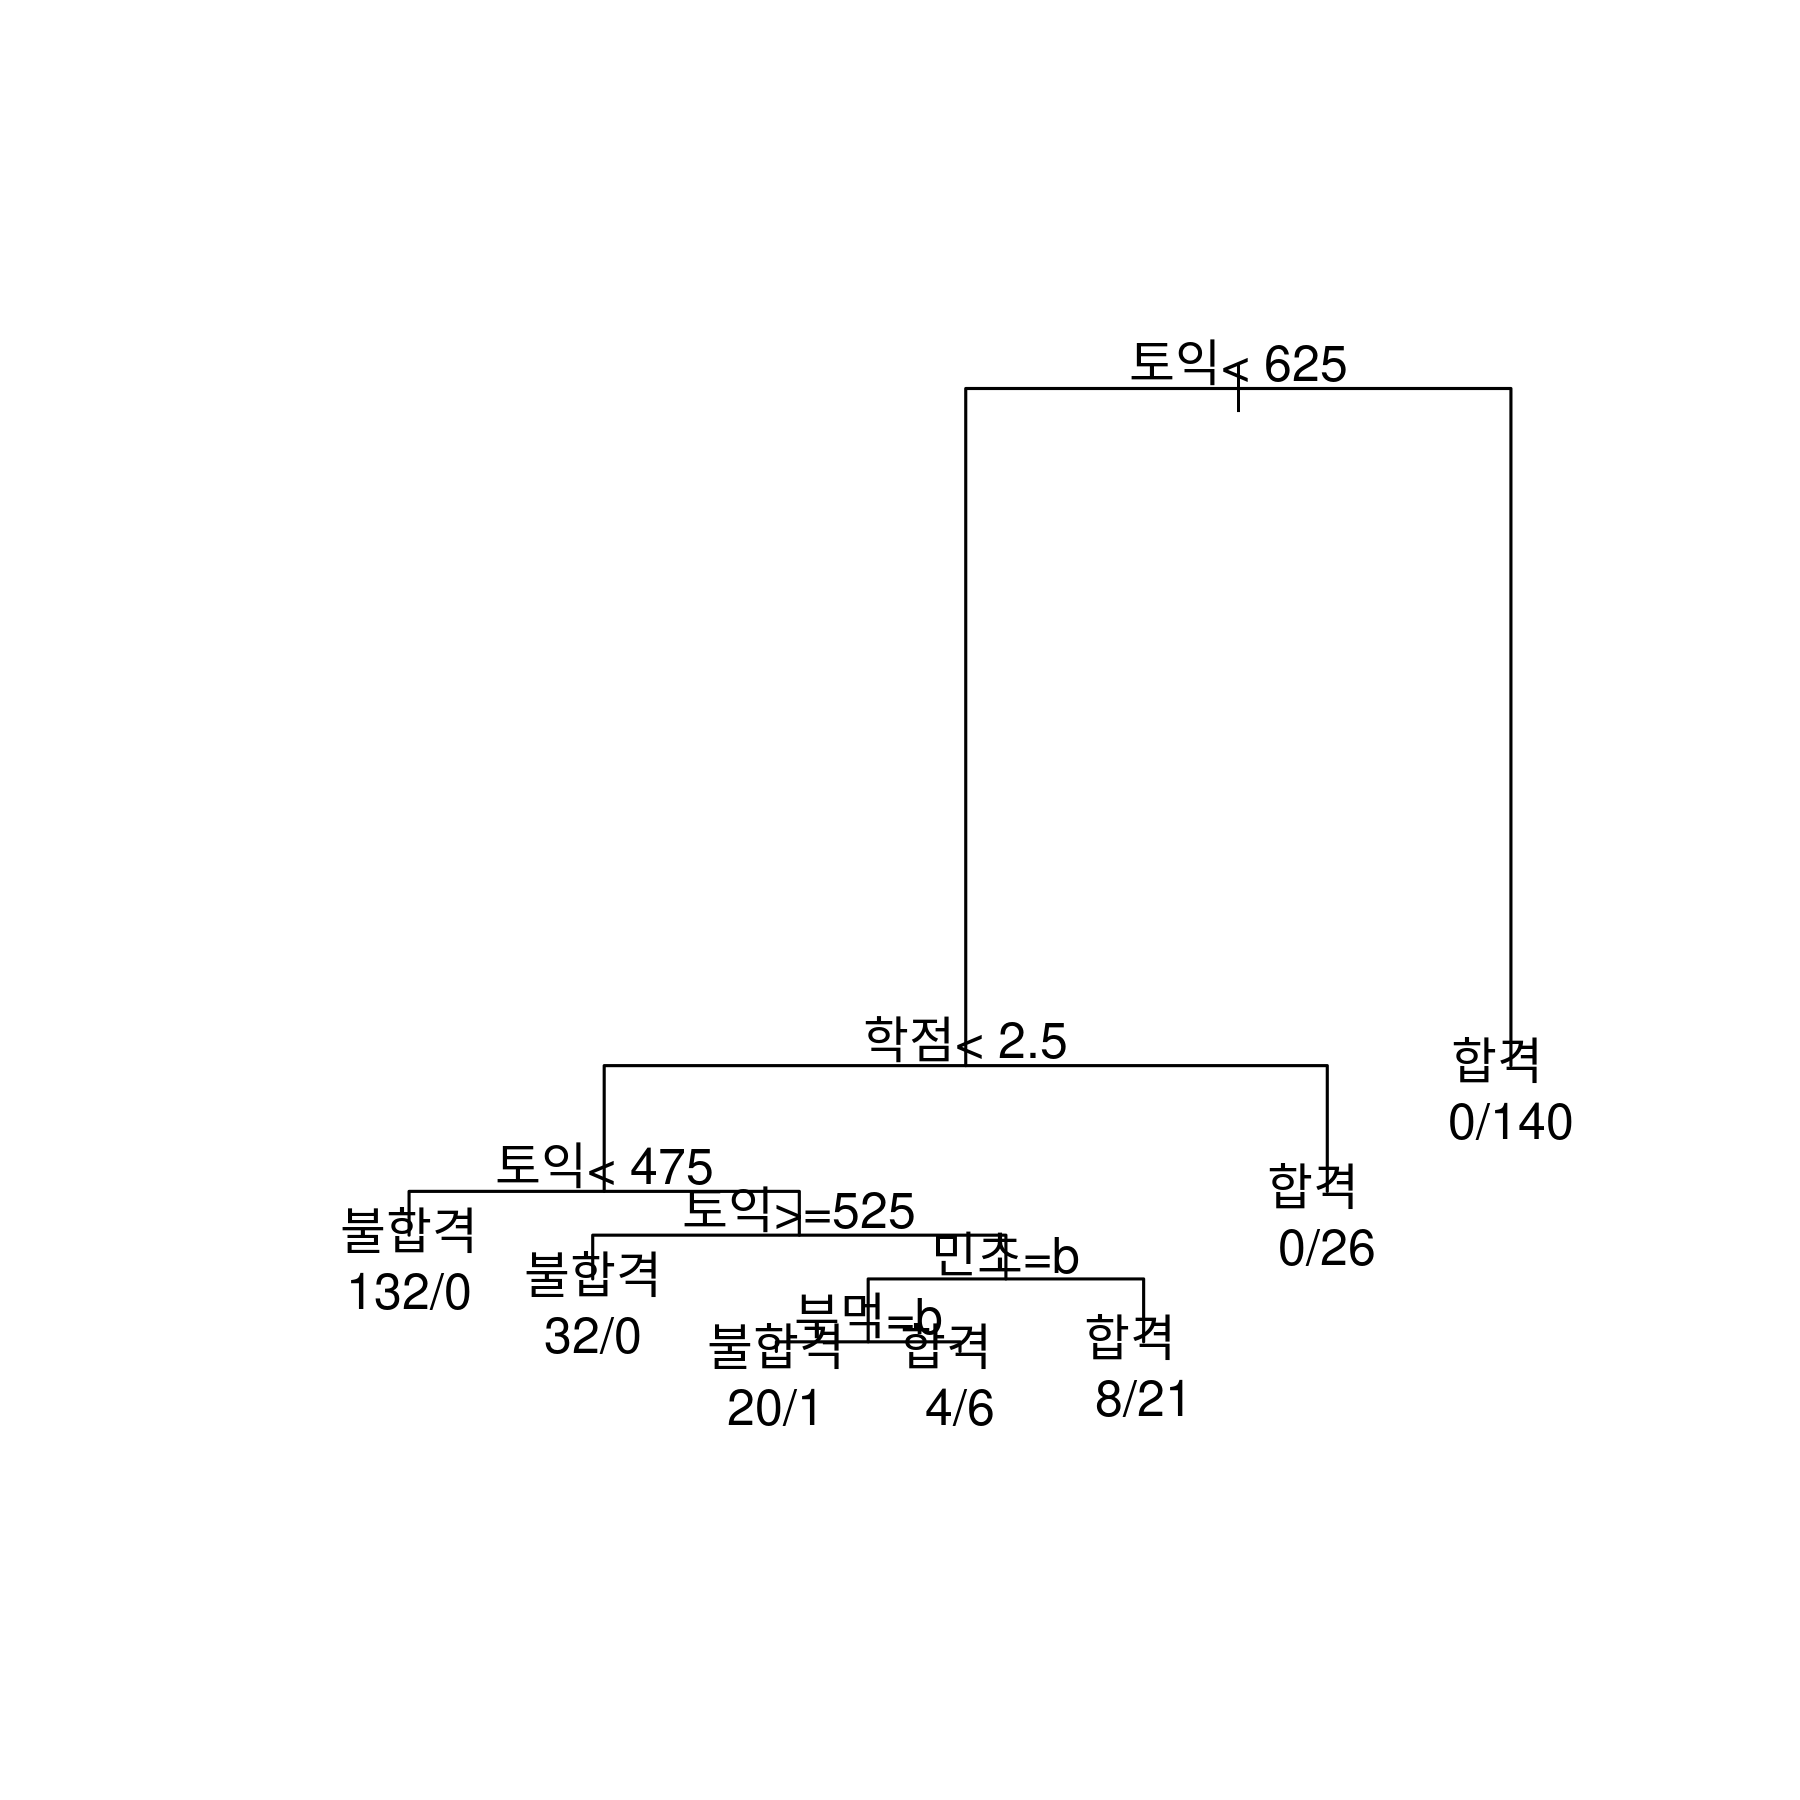

In [901]:
의사결정나무결과=rpart(data=부스트랩, 합격~.)
plot(의사결정나무결과,margin=0.1)
text(의사결정나무결과,use.n=T)

`-` 반복해보자. 

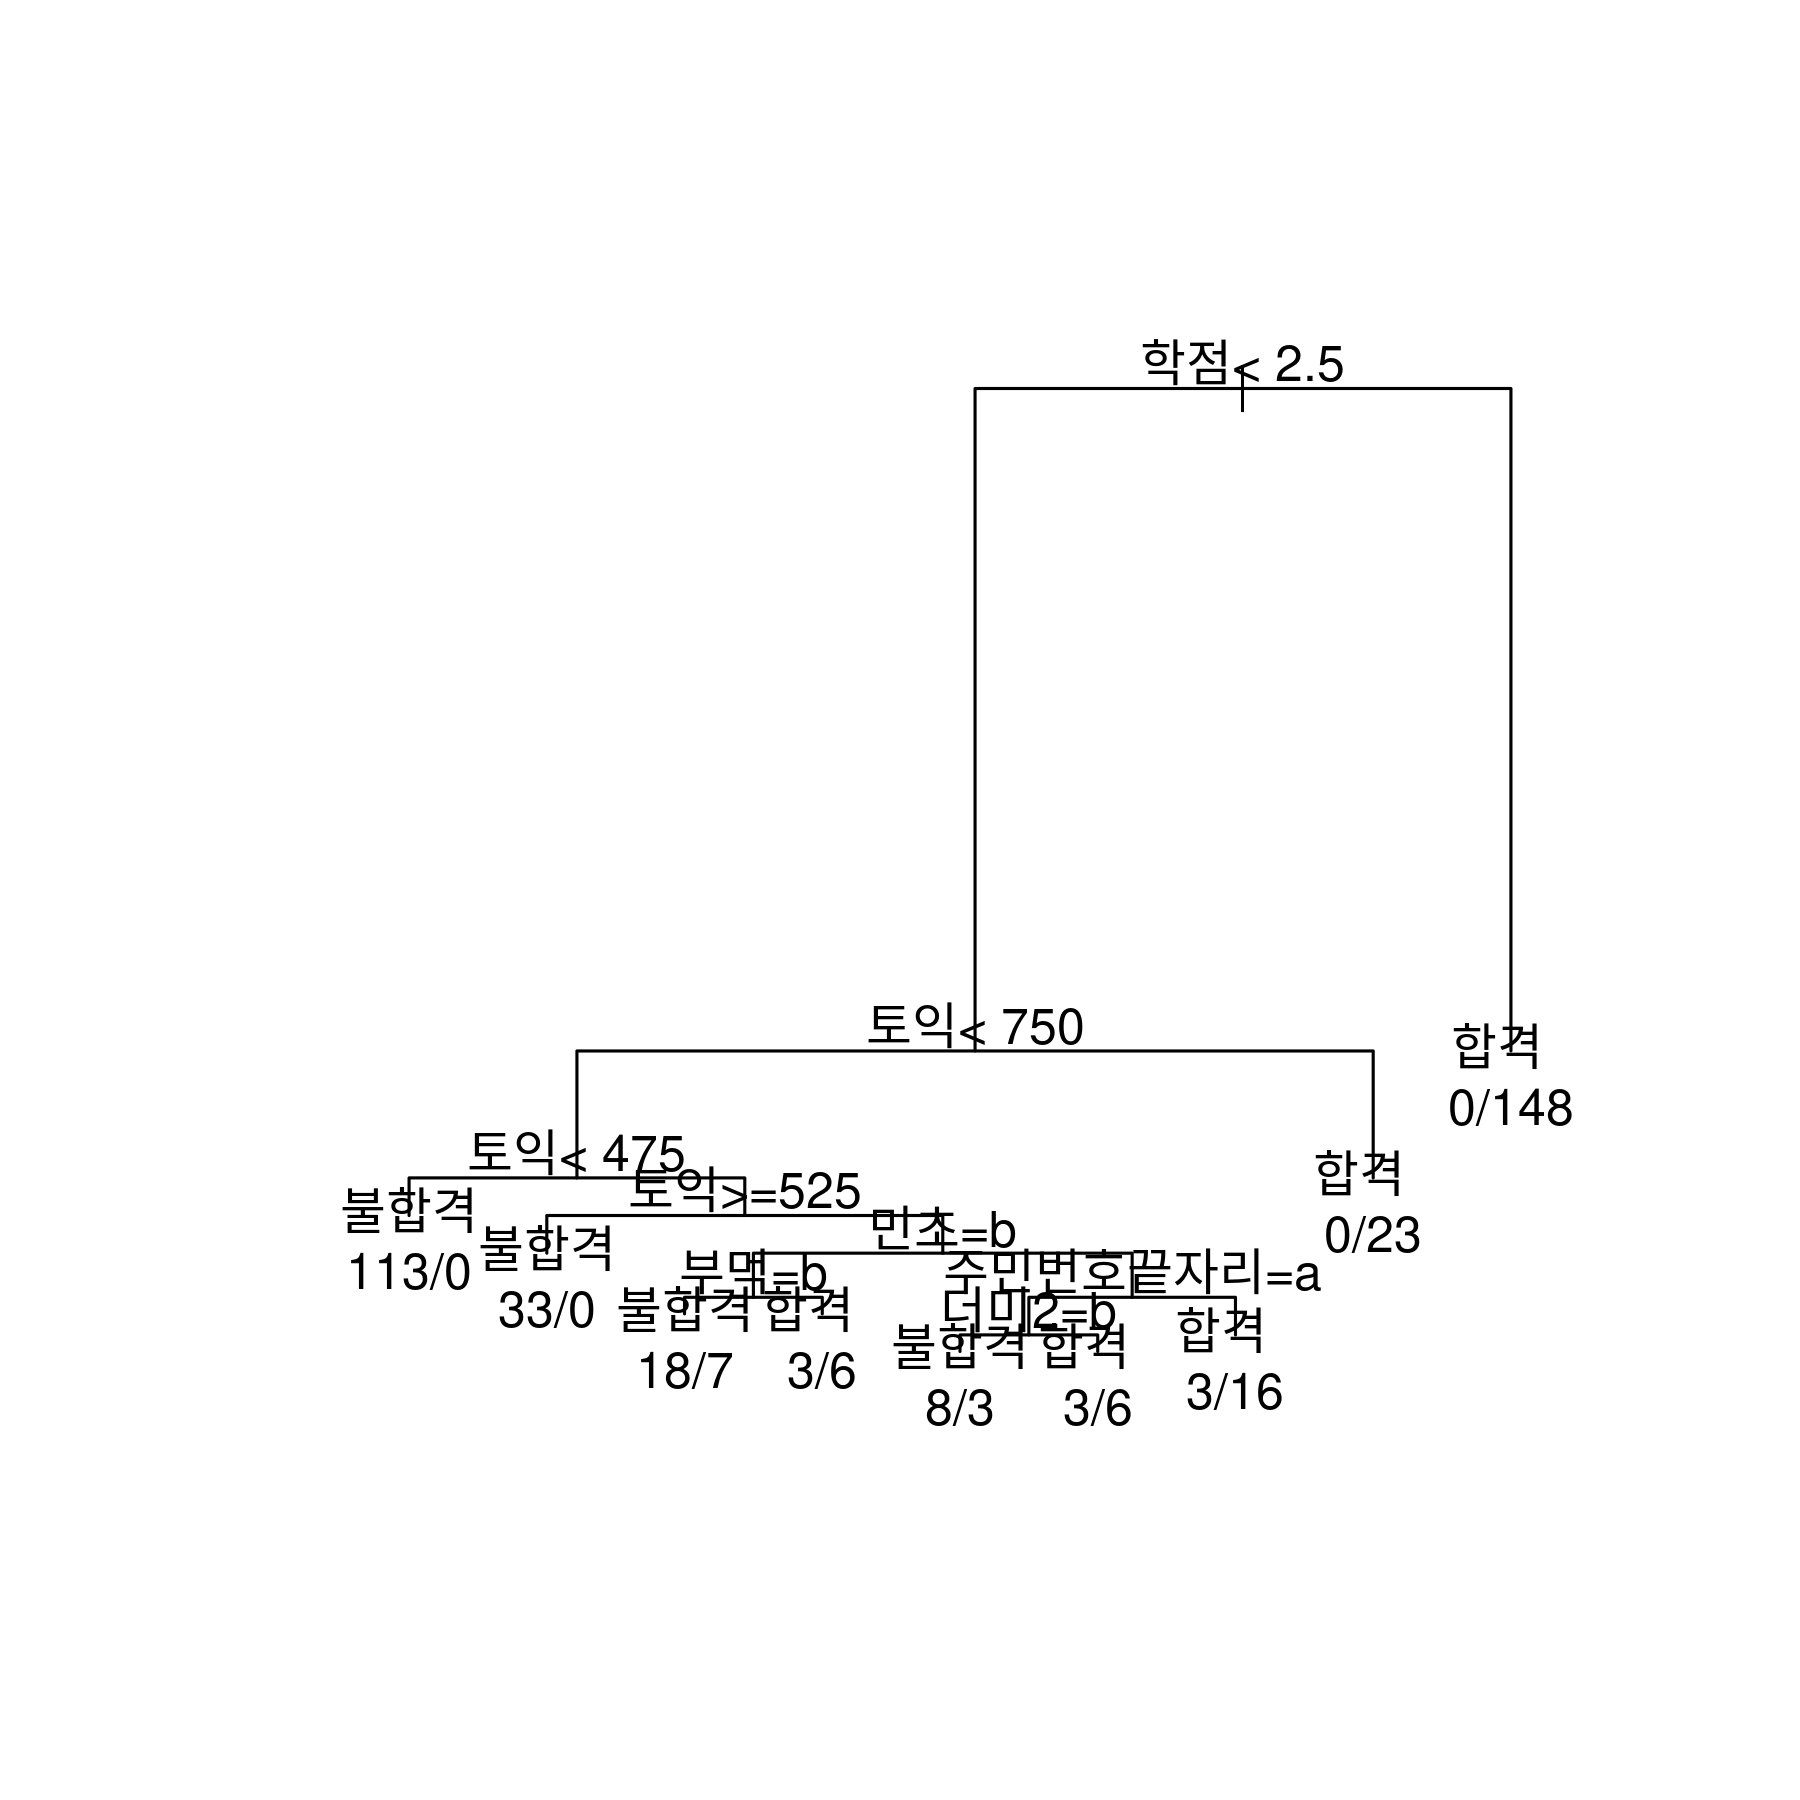

In [910]:
샘플링할인덱스=sort(sample(1:390,size=390,replace=T))
부스트랩=데이터2[샘플링할인덱스,]
의사결정나무결과=rpart(data=부스트랩, 합격~.)
plot(의사결정나무결과,margin=0.1)
text(의사결정나무결과,use.n=T)

- 다양하네요.. 

### 랜덤포레스트

In [913]:
library(randomForest)
randomForest(data=데이터2, 합격~., ntree=100)

ERROR: Error in library(randomForest): there is no package called ‘randomForest’
